# Stage 07 — Paired-CV Statistical Significance Tests

**Owner:** Sandesh Shahi (Analysis Lead)

**Design.**
- Each pair of models is evaluated on the **same** K-fold splits (seeded by `config.RANDOM_SEED`).
- The per-fold score differences are tested with `scipy.stats.ttest_rel` (paired t-test).
- Hypotheses:
  - $H_0$: the two models have equal mean score across folds — any observed difference is CV noise.
  - $H_1$: the two models have *different* mean scores.
- Significance level $\alpha = 0.05$.

**Model pairs (aligned with Weeks 1–5 taught methods):**
- **RQ1 — Simple LR vs Multiple LR**, scored by **MAE** (lower is better). A significant improvement means the extra predictors add genuine signal beyond the single strongest correlate.
- **RQ2 — Naive Bayes vs majority-class baseline**, scored by **accuracy** (higher is better). A significant improvement means NB learns something useful beyond "always predict the majority class".

**Inputs.** Checkpoints from notebook 03 (feature engineering).

**Outputs.** `data/processed/checkpoints/07_ttest_results.json` and `outputs/tables/paired_ttest_results.json`.

## 1. Setup

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, accuracy_score

from src import config, classification, evaluation, reporting

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

X      = _load("03_X.parquet")
y_reg  = _load("03_y_reg.parquet").iloc[:, 0]
y_cls  = _load("03_y_cls.parquet").iloc[:, 0]
mask   = y_cls.notna()
X_cls, y_cls = X.loc[mask].reset_index(drop=True), y_cls.loc[mask].astype(int).reset_index(drop=True)
print("Regression:", X.shape, "| Classification:", X_cls.shape)

Regression: (7971, 24) | Classification: (7971, 24)


## 2. RQ1 — Simple LR vs Multiple LR (paired-CV on MAE)

**Simple LR** uses the single feature with the strongest correlation with the target (same rule as notebook 05). **Multiple LR** uses the full engineered feature set. We score each on MAE per fold (lower is better) and apply a paired t-test.

Interpretation cheat-sheet:
- $p < 0.05$ with `mean_a > mean_b` on MAE → Multiple LR's MAE is *lower* than Simple LR's → the extra predictors materially help.
- $p \geq 0.05$ → extra predictors don't demonstrably help (or we need more folds / more data).

In [2]:
# Pick the Simple LR predictor the same way notebook 05 does
best_feature = X.apply(lambda c: c.corr(y_reg)).abs().sort_values(ascending=False).index[0]
X_simple = X[[best_feature]]
print(f"Simple LR predictor: {best_feature}")

ttest_reg = evaluation.paired_t_test_cv(
    model_a=LinearRegression(),          # Simple LR (1 predictor — see X_b)
    model_b=LinearRegression(),          # Multiple LR (all predictors)
    X=X_simple,
    X_b=X,
    y=y_reg,
    scoring_fn=mean_absolute_error,
    stratify=False,
    higher_is_better=False,              # lower MAE = better
    name_a="Simple LR",
    name_b="Multiple LR",
)
print(f"\nSimple LR   fold MAE: {[f'{s:.4f}' for s in ttest_reg['scores_a']]}   mean={ttest_reg['mean_a']:.4f}")
print(f"Multiple LR fold MAE: {[f'{s:.4f}' for s in ttest_reg['scores_b']]}   mean={ttest_reg['mean_b']:.4f}")
print(f"\nt = {ttest_reg['t_statistic']:.3f}   p = {ttest_reg['p_value']:.4f}")
print("Significant at α = 0.05:", ttest_reg['significant_at_0.05'])
print("Better model (lower mean MAE):", ttest_reg['better_model'])

Simple LR predictor: div_Health Care and Social Assistance
21:01:07 | INFO    | src.evaluation | Paired t-test Simple LR vs Multiple LR: mean_a=0.1784 mean_b=0.1432 t=18.571 p=0.0000

Simple LR   fold MAE: ['0.1782', '0.1808', '0.1749', '0.1821', '0.1759']   mean=0.1784
Multiple LR fold MAE: ['0.1419', '0.1509', '0.1413', '0.1406', '0.1414']   mean=0.1432

t = 18.571   p = 0.0000
Significant at α = 0.05: True
Better model (lower mean MAE): Multiple LR


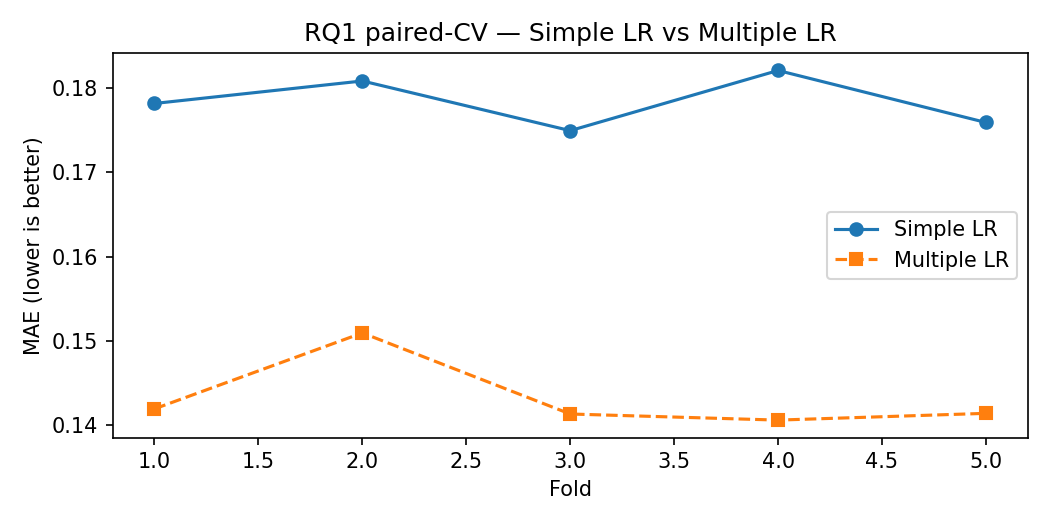

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
folds = np.arange(1, len(ttest_reg['scores_a']) + 1)
ax.plot(folds, ttest_reg['scores_a'], "o-", label="Simple LR")
ax.plot(folds, ttest_reg['scores_b'], "s--", label="Multiple LR")
ax.set_xlabel("Fold"); ax.set_ylabel("MAE (lower is better)")
ax.set_title("RQ1 paired-CV — Simple LR vs Multiple LR")
ax.legend(); plt.tight_layout()
fig_path = config.FIG_DIR / "rq1_ttest_folds.png"
fig.savefig(fig_path, dpi=150); plt.close(fig)
from IPython.display import Image, display
display(Image(str(fig_path)))

## 3. RQ2 — Naive Bayes vs Majority-Class Baseline (paired-CV on accuracy)

The majority-class baseline (`DummyClassifier(strategy="most_frequent")`) always predicts whichever class is most common in the training fold. Any useful classifier should beat this. The paired t-test asks whether Naive Bayes' lift over the baseline is larger than CV noise.

In [4]:
from sklearn.naive_bayes import GaussianNB

ttest_cls = evaluation.paired_t_test_cv(
    model_a=GaussianNB(),
    model_b=classification.majority_class_baseline(),
    X=X_cls,
    y=y_cls,
    scoring_fn=accuracy_score,
    stratify=True,
    higher_is_better=True,
    name_a="NaiveBayes",
    name_b="MajorityBaseline",
)
print(f"NB       fold acc: {[f'{s:.4f}' for s in ttest_cls['scores_a']]}   mean={ttest_cls['mean_a']:.4f}")
print(f"Baseline fold acc: {[f'{s:.4f}' for s in ttest_cls['scores_b']]}   mean={ttest_cls['mean_b']:.4f}")
print(f"\nt = {ttest_cls['t_statistic']:.3f}   p = {ttest_cls['p_value']:.4f}")
print("Significant at α = 0.05:", ttest_cls['significant_at_0.05'])
print("Better model (higher mean accuracy):", ttest_cls['better_model'])

21:01:08 | INFO    | src.evaluation | Paired t-test NaiveBayes vs MajorityBaseline: mean_a=0.7322 mean_b=0.5031 t=78.991 p=0.0000
NB       fold acc: ['0.7310', '0.7215', '0.7340', '0.7371', '0.7371']   mean=0.7322
Baseline fold acc: ['0.5028', '0.5031', '0.5031', '0.5031', '0.5031']   mean=0.5031

t = 78.991   p = 0.0000
Significant at α = 0.05: True
Better model (higher mean accuracy): NaiveBayes


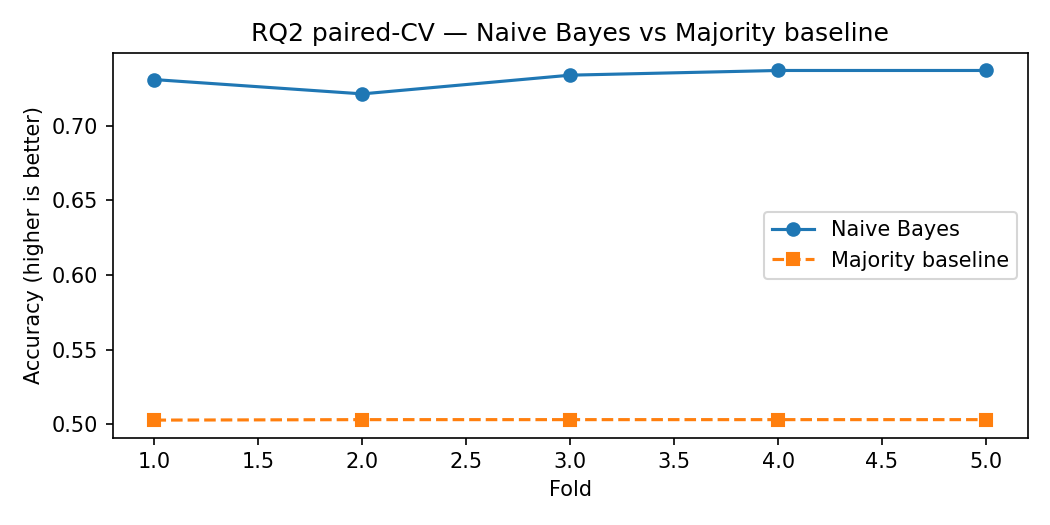

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
folds = np.arange(1, len(ttest_cls['scores_a']) + 1)
ax.plot(folds, ttest_cls['scores_a'], "o-", label="Naive Bayes")
ax.plot(folds, ttest_cls['scores_b'], "s--", label="Majority baseline")
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy (higher is better)")
ax.set_title("RQ2 paired-CV — Naive Bayes vs Majority baseline")
ax.legend(); plt.tight_layout()
fig_path = config.FIG_DIR / "rq2_ttest_folds.png"
fig.savefig(fig_path, dpi=150); plt.close(fig)
display(Image(str(fig_path)))

## 4. Consolidated results table

In [6]:
summary = pd.DataFrame([
    {
        "comparison": "RQ1 — Simple LR vs Multiple LR (MAE, lower better)",
        "mean_a": ttest_reg["mean_a"], "mean_b": ttest_reg["mean_b"],
        "t": ttest_reg["t_statistic"], "p": ttest_reg["p_value"],
        "sig_0.05": ttest_reg["significant_at_0.05"], "better": ttest_reg["better_model"],
    },
    {
        "comparison": "RQ2 — Naive Bayes vs Majority baseline (accuracy)",
        "mean_a": ttest_cls["mean_a"], "mean_b": ttest_cls["mean_b"],
        "t": ttest_cls["t_statistic"], "p": ttest_cls["p_value"],
        "sig_0.05": ttest_cls["significant_at_0.05"], "better": ttest_cls["better_model"],
    },
]).round(4)
summary

,comparison,mean_a,mean_b,t,p,sig_0.05,better
0,"RQ1 — Simple LR vs Multiple LR (MAE, lower bet...",0.1784,0.1432,18.5707,0.0,True,Multiple LR
1,RQ2 — Naive Bayes vs Majority baseline (accuracy),0.7322,0.5031,78.9914,0.0,True,NaiveBayes


## 5. Checkpoint

In [7]:
results = {
    "rq1_simple_vs_multiple_lr": ttest_reg,
    "rq2_naive_bayes_vs_baseline": ttest_cls,
}
with open(config.CHECKPOINT_DIR / "07_ttest_results.json", "w") as f:
    json.dump(results, f, indent=2)
reporting.write_ttest_results(ttest_reg, ttest_cls)
print("Saved t-test results.")

21:01:08 | INFO    | src.reporting | Paired t-test results → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\outputs\tables\paired_ttest_results.json
Saved t-test results.


## How to phrase this on the slide

*"Using 5-fold cross-validation on identical folds, we compared each model against a simpler baseline and applied a paired t-test (H₀: equal mean performance, α = 0.05).*

- *RQ1: Multiple LR reached mean MAE `X`, versus Simple LR's `Y`, t = `t`, p = `p`. We {reject / fail to reject} H₀, concluding the full feature set {does / does not} significantly improve prediction of women-in-management.*
- *RQ2: Naive Bayes reached mean accuracy `X`, versus the majority baseline's `Y`, t = `t`, p = `p`. We {reject / fail to reject} H₀, concluding NB {does / does not} significantly outperform the baseline."*

**Next:** `08_reporting.ipynb` — consolidate everything into the final metrics summary for the slide deck.